# k-Vecinos Más Cercanos : k-Nearest Neighbors (kNN)

Angélica Mata Zamora

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn.datasets
from sklearn.model_selection import train_test_split  
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

#import ML

In [2]:
N=1000
noisy_data = sklearn.datasets.make_moons(n_samples=N, noise=.23, random_state=23) 

X, Y = noisy_data

print(X.shape)
print(Y.shape)

(1000, 2)
(1000,)


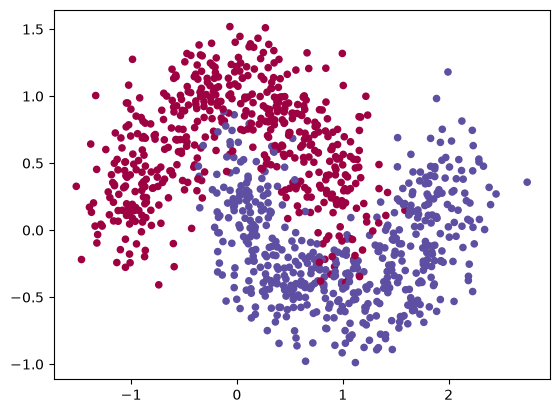

In [3]:
plt.scatter(X[:,0], X[:,1], c=Y, s=20, cmap=plt.cm.Spectral);

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=.60)

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(600, 2)
(600,)
(400, 2)
(400,)


In [5]:
modelo_kNN = KNeighborsClassifier(n_neighbors=3)

modelo_kNN.fit(X_train, Y_train)

print(modelo_kNN.score(X_train, Y_train))
print(modelo_kNN.score(X_test, Y_test))

0.9566666666666667
0.9475


In [6]:
for k in range(1,16):
  modelo_kNN = KNeighborsClassifier(n_neighbors=k)
  modelo_kNN.fit(X_train, Y_train)

  trs = modelo_kNN.score(X_train, Y_train)
  tes = modelo_kNN.score(X_test, Y_test)

  print('k=%d\tTrain: %.4f\tTest: %.4f' % (k, trs, tes))

k=1	Train: 1.0000	Test: 0.9350
k=2	Train: 0.9550	Test: 0.9300
k=3	Train: 0.9567	Test: 0.9475
k=4	Train: 0.9517	Test: 0.9550
k=5	Train: 0.9533	Test: 0.9525
k=6	Train: 0.9550	Test: 0.9575
k=7	Train: 0.9533	Test: 0.9575
k=8	Train: 0.9500	Test: 0.9575
k=9	Train: 0.9533	Test: 0.9525
k=10	Train: 0.9500	Test: 0.9550
k=11	Train: 0.9550	Test: 0.9475
k=12	Train: 0.9433	Test: 0.9475
k=13	Train: 0.9483	Test: 0.9475
k=14	Train: 0.9467	Test: 0.9450
k=15	Train: 0.9467	Test: 0.9475


## Grid Search

In [7]:
from sklearn.model_selection import GridSearchCV

In [8]:
dicc_grid = {'n_neighbors':[1,3,5,7,9,11], 
              'weights':['uniform', 'distance'],  
              'metric':['euclidean', 'manhattan']}

kNN = KNeighborsClassifier()

modelo_kNN = GridSearchCV(kNN, param_grid=dicc_grid, cv=3)

modelo_kNN.fit(X_train,Y_train)

print("Los mejores parametros son %s con un score de %0.2f"
      % (modelo_kNN.best_params_, modelo_kNN.best_score_))

Los mejores parametros son {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'} con un score de 0.94


In [9]:
kNN2 = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance')

kNN2.fit(X_train, Y_train)

print(modelo_kNN.score(X_train, Y_train))
print(modelo_kNN.score(X_test, Y_test))

0.9583333333333334
0.9575


## Randomized Grid Search

In [10]:
from sklearn.model_selection import RandomizedSearchCV

In [11]:
dicc_grid = {'n_neighbors':[1,3,5,7,9,11,13,15,17], 
             'weights':['uniform', 'distance'],  
             'metric':['euclidean', 'manhattan'],
             'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute']
             }

kNN = KNeighborsClassifier()

modelo_kNN = RandomizedSearchCV(kNN, 
                                param_distributions= dicc_grid,    # en este ejemplo tenemos 9x2x2x4=144 combinaciones posibles.
                                cv=5,         # Cross-Validation 
                                n_iter= 20     # n_iter=total de valores que se seleccionarán del grid.
                                ) 

modelo_kNN.fit(X_train,Y_train)

print("Los mejores parametros son %s \ncon un score de %0.2f"
      % (modelo_kNN.best_params_, modelo_kNN.best_score_))

Los mejores parametros son {'weights': 'uniform', 'n_neighbors': 17, 'metric': 'manhattan', 'algorithm': 'kd_tree'} 
con un score de 0.95


In [12]:
kNN2 = KNeighborsClassifier(n_neighbors=11, metric='euclidean', weights='distance', algorithm='brute')

kNN2.fit(X_train, Y_train)

print(modelo_kNN.score(X_train, Y_train))
print(modelo_kNN.score(X_test, Y_test))

0.9516666666666667
0.9475
